In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [2]:
#set some styles for our plots
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

In [3]:
#load the dataset
ds = pd.read_csv("Air_Quality.csv")

ds.head()

,Date,City,CO,NO2,SO2,O3,PM2.5,PM10,AQI
0,2023-01-01 00:00:00+00:00,Brasilia,292.0,30.15,1.10,23.0,11.1,15.8,21.158330
1,2023-01-01 01:00:00+00:00,Brasilia,291.0,28.95,1.15,24.0,12.4,17.7,20.825000
2,2023-01-01 02:00:00+00:00,Brasilia,289.0,27.25,1.25,25.0,13.0,18.5,20.474998
3,2023-01-01 03:00:00+00:00,Brasilia,275.0,23.70,1.30,28.0,9.2,13.1,20.074999
4,2023-01-01 04:00:00+00:00,Brasilia,246.0,19.35,1.25,32.0,6.8,9.7,19.324999


In [4]:
#convert date to date time to normalize
ds['Date'] = pd.to_datetime(ds["Date"], errors = "coerce")

#drop rows with no dates
ds.dropna(subset = ['Date'], inplace = True)

In [5]:
#sort values based on citry and date
ds.sort_values(['City', 'Date'], inplace = True)

#get a list of the cities
cities = ds['City'].unique()

In [6]:
#define a color palette per city
palette = sns.color_palette("tab10", len(cities))

#a dict to assign a specific color to a city
city_colors = {city : palette[i] for i, city in enumerate(cities)}

#create a place holder for graphs
results = {}

In [9]:
#define a loop to train on each city
for city in cities:
    city_ds = ds[ds['City'] == city].copy()

    #get the features (leave out PM 2.5 since it is the target for this study)
    city_ds = city_ds[['Date', 'PM2.5', 'CO', 'NO2', 'SO2', 'O3', 'PM10']]
    city_ds.dropna(subset=['PM2.5'], inplace=True)
    city_ds.fillna(method='ffill', inplace=True)
    city_ds.sort_values('Date', inplace=True) 

    #extract time features
    city_ds['hour'] = city_ds['Date'].dt.hour
    city_ds['dayofweek'] = city_ds['Date'].dt.dayofweek
    city_ds['month'] = city_ds['Date'].dt.month

    #generate lag features for pm2.5
    #lag is the past value we want to predict 
    #24 hour range
    for lag in range(1,25):
        city_ds[f"lag_{lag}"] = city_ds['PM2.5'].shift(lag)

    city_ds.dropna(inplace = True)

    features = ['CO', 'NO2', 'SO2', 'O3', 'PM10', 'hour', 'dayofweek', 'month'] + [f'lag_{i}' for i in range(1, 25)]
    X = city_ds[features]
    y = city_ds['PM2.5']
    dates = city_ds['Date']

    #train test splits
    #we cant use tran test split func since it shuffles data, which we need to be orderred for a time series prediction
    split_idx = int(len(city_ds) * 0.8)
    X_train,X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    dates_test = dates.iloc[split_idx:]

    #use xgboost
    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        tree_method='gpu_hist',        # GPU training
        predictor='gpu_predictor',     # GPU prediction
        gpu_id=0,                      # GPU device index
        random_state=42,
        verbosity=0
    )
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)


    #save the results
    results[city] = {
        'date': dates_test.values,
        'actual': y_test.values,
        'predicted': y_pred,
        'mae': mean_absolute_error(y_test, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_test, y_pred))
    }

C:\Users\Jomar\AppData\Local\Temp\ipykernel_14644\2004158131.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  city_ds.fillna(method='ffill', inplace=True)
C:\Users\Jomar\AppData\Local\Temp\ipykernel_14644\2004158131.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  city_ds.fillna(method='ffill', inplace=True)
C:\Users\Jomar\AppData\Local\Temp\ipykernel_14644\2004158131.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  city_ds.fillna(method='ffill', inplace=True)
C:\Users\Jomar\AppData\Local\Temp\ipykernel_14644\2004158131.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  city_ds.fillna(method='ffill', inplace=True)


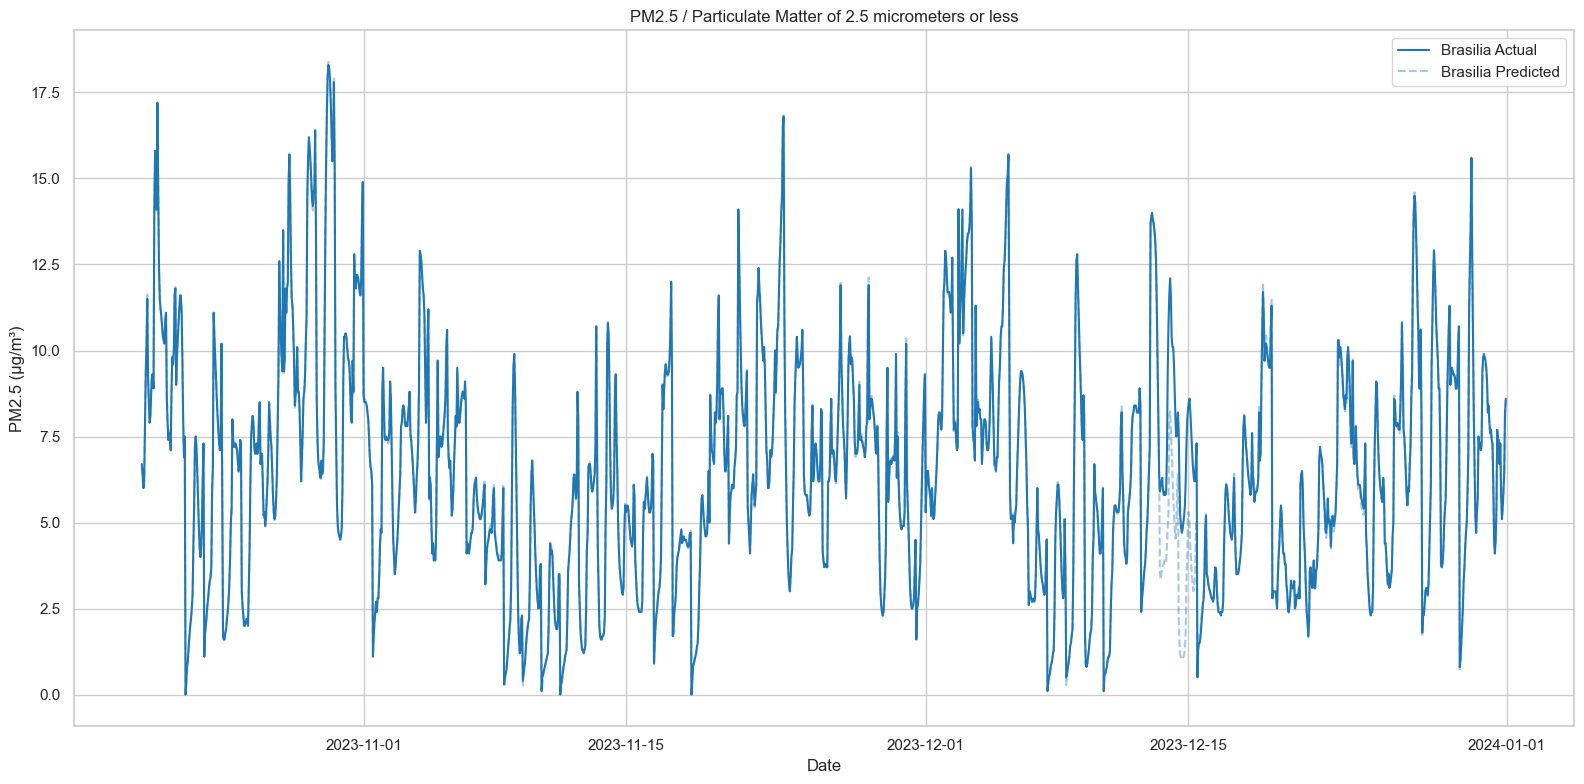

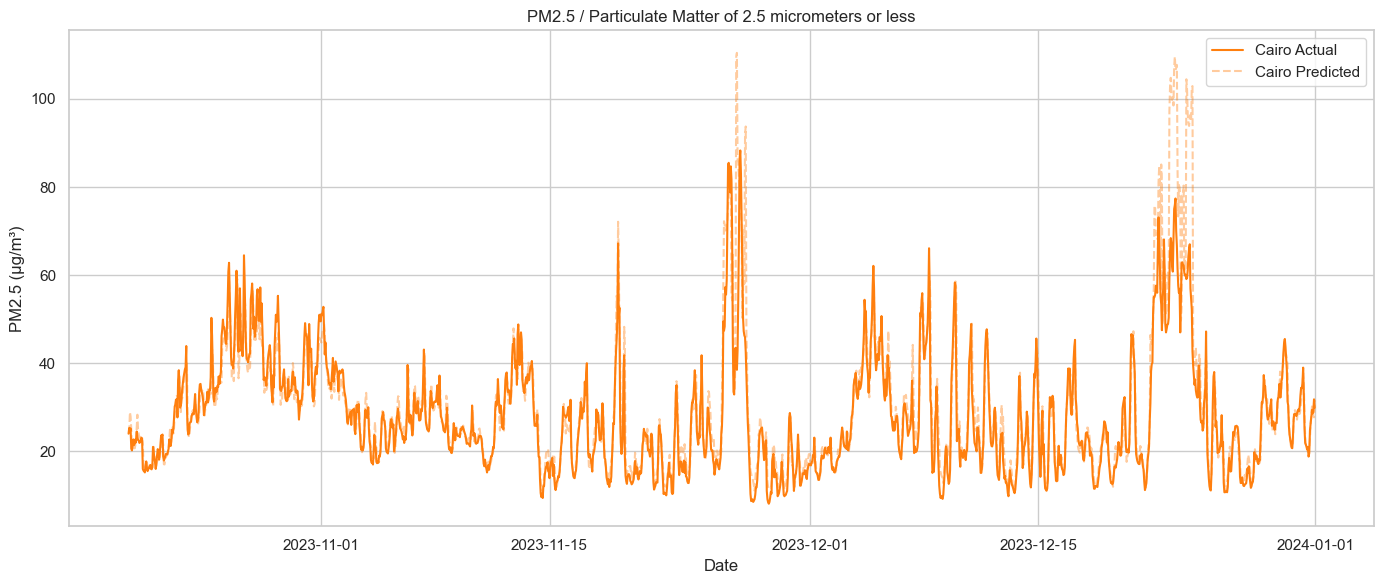

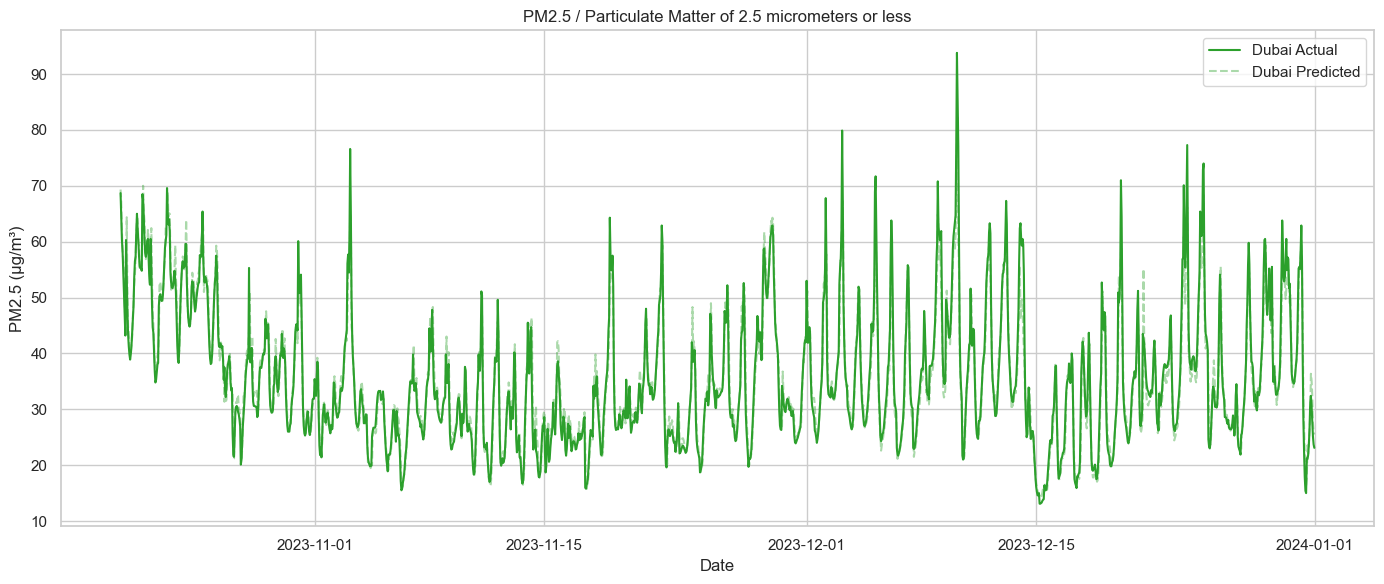

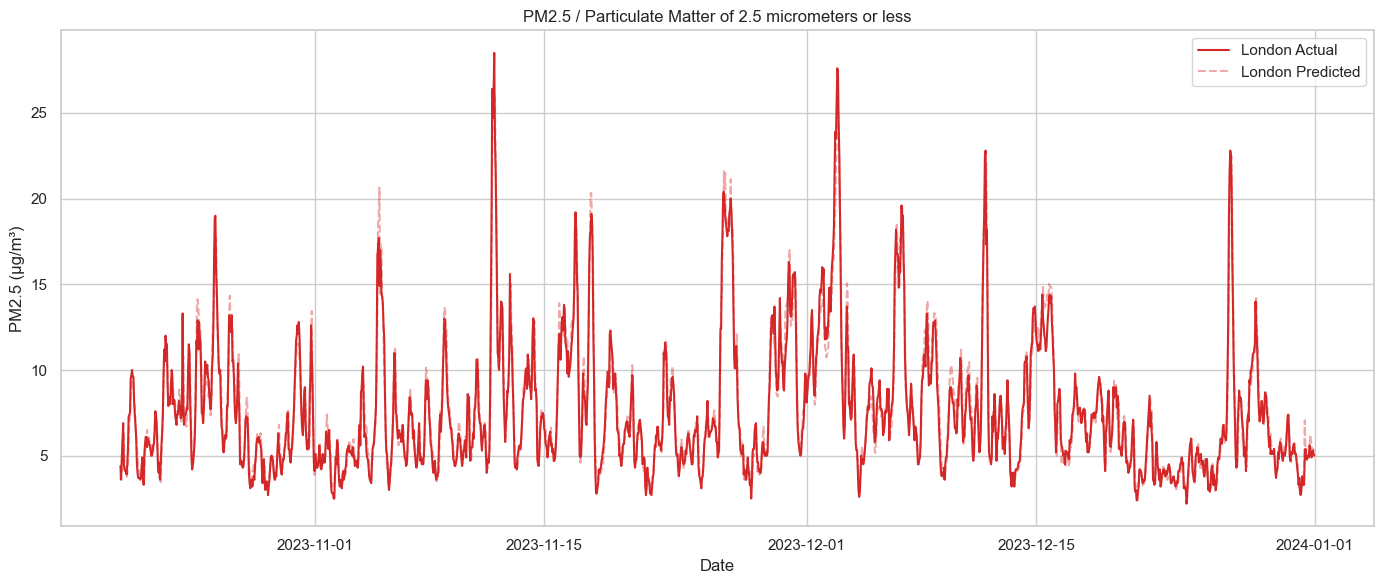

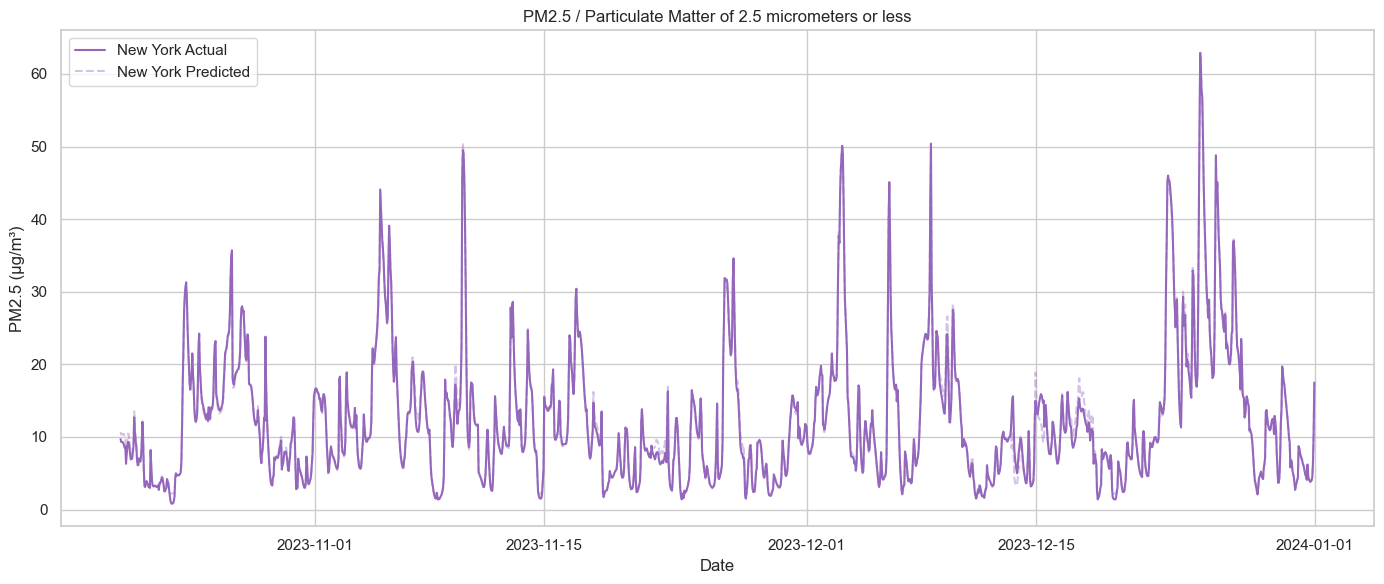

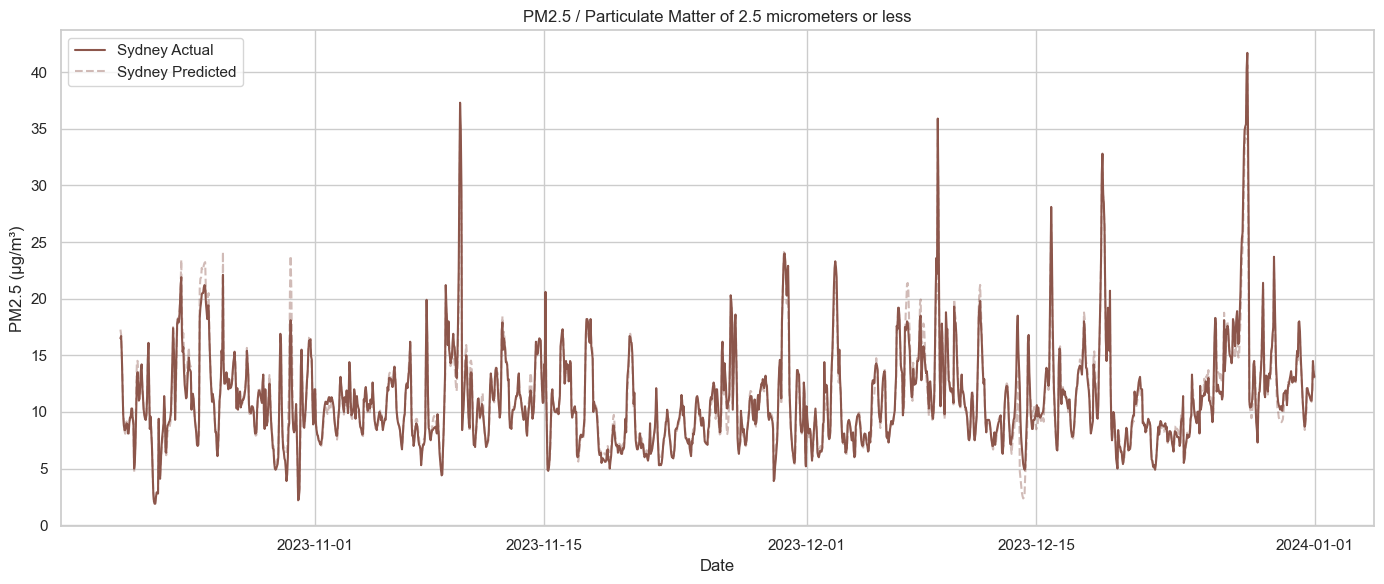

In [11]:
#plot the results
plt.figure(figsize = (16,8))
for city in cities:
    r = results[city]
    color = city_colors[city]
    plt.plot(r['date'], r['actual'], label=f'{city} Actual', color=color)
    #predicted will have lighter colors so set alpha
    plt.plot(r['date'], r['predicted'], label=f'{city} Predicted', color=color, linestyle='--', alpha=0.4)

    plt.title("PM2.5 / Particulate Matter of 2.5 micrometers or less")
    plt.xlabel("Date")
    plt.ylabel("PM2.5 (µg/m³)")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [12]:
#show some performance 
print("\nModel Performance by City:")
for city in cities:
    print(f"{city}: MAE = {results[city]['mae']:.2f}, RMSE = {results[city]['rmse']:.2f}")


Model Performance by City:
Brasilia: MAE = 0.14, RMSE = 0.58
Cairo: MAE = 3.21, RMSE = 6.76
Dubai: MAE = 1.89, RMSE = 2.85
London: MAE = 0.62, RMSE = 0.86
New York: MAE = 0.36, RMSE = 0.70
Sydney: MAE = 0.55, RMSE = 0.88
